# 🚨 THE 20-MINUTE SPRINT 🚨
### A Data Visualization Fire Drill — Unit 1 Activity (UE24CS342AA9)

---

**08:47 AM.** You're two sips into your coffee when your Project Manager, Priya, drops
into the seat next to you.

> *"Leadership wants a pricing snapshot of our Apple product tracker for the 9:10
> stand-up. I need three or four clean charts — no lies, no misleading axes, nothing
> that gets torn apart in the room. You've got until 9:07. Go."*

It's **9:07 AM**. That's **20 minutes**, starting now.

You have one dataset (`apple_products_pricing_2020_2026.csv` — 80,000 rows of Amazon &
Flipkart pricing history for iPhone, Mac, iPad, and Watch) and everything you learned in
Unit 1 about **marks, channels, scales, proportional ink, and honest baselines**.

Leadership has seen bad charts before. They will notice a truncated bar axis. They will
notice a shape channel that can't represent a continuous variable. **Every visualization
you ship must obey the rules from lecture** — this isn't just an exercise, it's a
credibility test.

---

### 🎯 Mission Rules
1. Work through **Tasks 1–4** below, in order. Each has a suggested time box — keep moving.
2. Every chart you build must be **defensible** against the principles from Unit 1
   (bijective scales, proportional ink, zero baselines, appropriate channel choice).
3. At **Task 5**, do the honest self-audit before you "submit."
4. Finish with the **Reflection** section — that's where the real grade lives.

Ready? Run the setup cell and **start your timer**.


In [26]:
# --- MISSION SETUP: run this first, then start your 20-minute timer ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv('data.csv', parse_dates=["Date"])

mission_start = time.time()
print("⏱️  MISSION CLOCK STARTED.")
print(f"Loaded {len(df):,} rows. You have 20 minutes. Go.")


⏱️  MISSION CLOCK STARTED.
Loaded 80,000 rows. You have 20 minutes. Go.


C:\Users\divya\AppData\Local\Temp\ipykernel_23612\3436769773.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('data.csv', parse_dates=["Date"])


In [27]:
# Run this cell any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 20 - elapsed_min)
bar = "🟩" * int(remaining) + "⬜" * (20 - int(remaining))
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")
print(bar)
if remaining < 5:
    print("⚠️  Under 5 minutes -- wrap up your current chart and move to Task 5.")


Elapsed: 0.3 min   |   Remaining: 19.7 min
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜


---
## Task 1 — Know Your Variables *(~3 min)*

Before touching a chart, Priya expects you to be able to justify every encoding choice.
Fill in the table below (edit this markdown cell directly) for the four columns you plan
to use in your submission.

| Column you'll use | Variable type (continuous / discrete quantitative / ordered / unordered qualitative) | Channel you plan to map it to |
|---|---|---|
| *e.g. Current_Price_USD* | *e.g. Continuous quantitative* | *e.g. y-position* |
| | | |
| | | |
| | | |

**Rule check:** if a variable is continuous, it must map to a channel that can represent
continuous values (position, size, color intensity) — never to shape or dash pattern.


---
## Task 2 — The Headline Bar Chart *(~5 min)*

Leadership always looks at the bar chart first. Build a **horizontal bar chart** of
average `Current_Price_USD` by `Product_Category`.

**Non-negotiable:** the baseline must be zero. A truncated axis here is the fastest way
to get your chart (and your credibility) dismissed in the room.

Fill in the `# TODO` lines below.


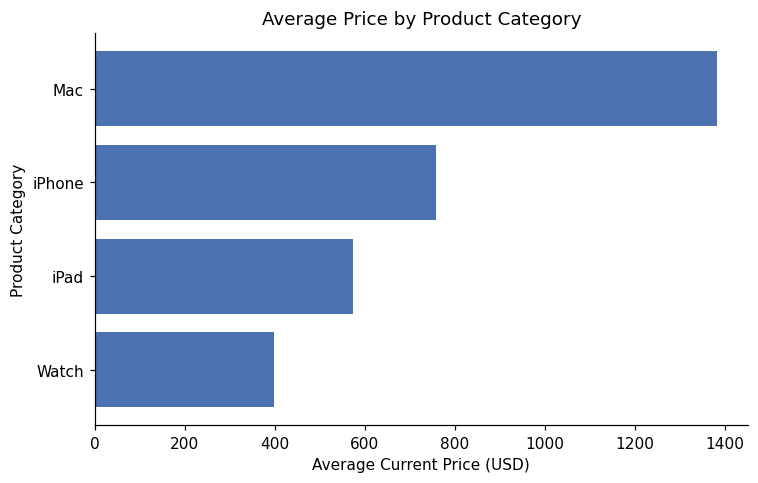

In [31]:
# Compute average Current_Price_USD grouped by Product_Category, sorted ascending
cat_avg = df.groupby("Product_Category")["Current_Price_USD"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))

# Horizontal bar chart
ax.barh(cat_avg.index, cat_avg.values, color="#4C72B0")

# Enforce the zero-baseline rule (x-axis holds the values here)
ax.set_xlim(left=0)

ax.set_xlabel("Average Current Price (USD)")
ax.set_ylabel("Product Category")
ax.set_title("Average Price by Product Category")
plt.tight_layout()
plt.show()

---
## Task 3 — The Trend Line, Done Right *(~5 min)*

Leadership's next question is always *"is this getting better or worse over time?"*
Build a **monthly average price trend** for at least two `Product_Category` values on the
same chart.

**Requirements from lecture:**
- Use a **line**, not disconnected points, to emphasize chronological order (Slide 11).
- Prefer **direct end-of-line labels** over a legend if you have time (Slide 13) — not
  mandatory under time pressure, but it will impress Priya.
- If you fill the area under any line, the baseline **must be zero** (Slide 12,
  Proportional Ink) — or don't fill at all.


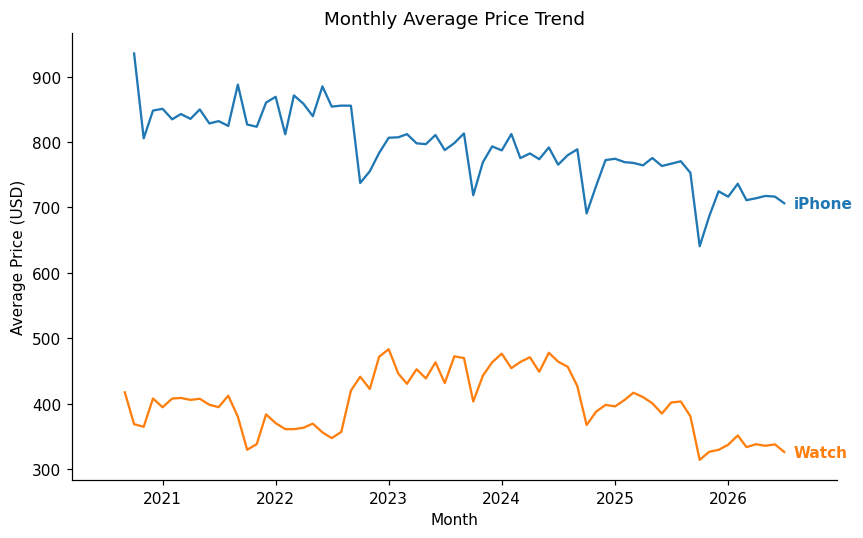

In [32]:
categories_to_plot = ["iPhone", "Watch"]

df["Date"] = pd.to_datetime(df["Date"])

fig, ax = plt.subplots(figsize=(8, 5))

for cat in categories_to_plot:
    monthly = (df[df["Product_Category"] == cat]
               .set_index("Date")
               .resample("MS")["Current_Price_USD"]
               .mean())
    line, = ax.plot(monthly.index, monthly.values, linewidth=1.5, label=cat)

    # Direct end label at the last point, in the line's own color
    last_x, last_y = monthly.index[-1], monthly.values[-1]
    ax.annotate(cat, xy=(last_x, last_y), xytext=(6, 0),
                textcoords="offset points", va="center",
                color=line.get_color(), fontweight="bold")

# Give labels room to breathe without clipping
ax.margins(x=0.08)

ax.set_xlabel("Month")
ax.set_ylabel("Average Price (USD)")
ax.set_title("Monthly Average Price Trend")
plt.tight_layout()
plt.show()


---
## Task 4 — The "Wow" Multi-Variable Chart *(~5 min)*

Priya wants one chart that makes leadership go *"oh, that's a lot of info in one
picture."* Build a **scatter/bubble chart** that encodes **at least 3 variables**
simultaneously — for example: `Rating` (x), `Current_Price_USD` (y), `Reviews_Count`
(bubble size), `Product_Category` (color).

**Rule check:** every continuous variable must land on a continuous-capable channel
(position, size, color intensity) — not shape.


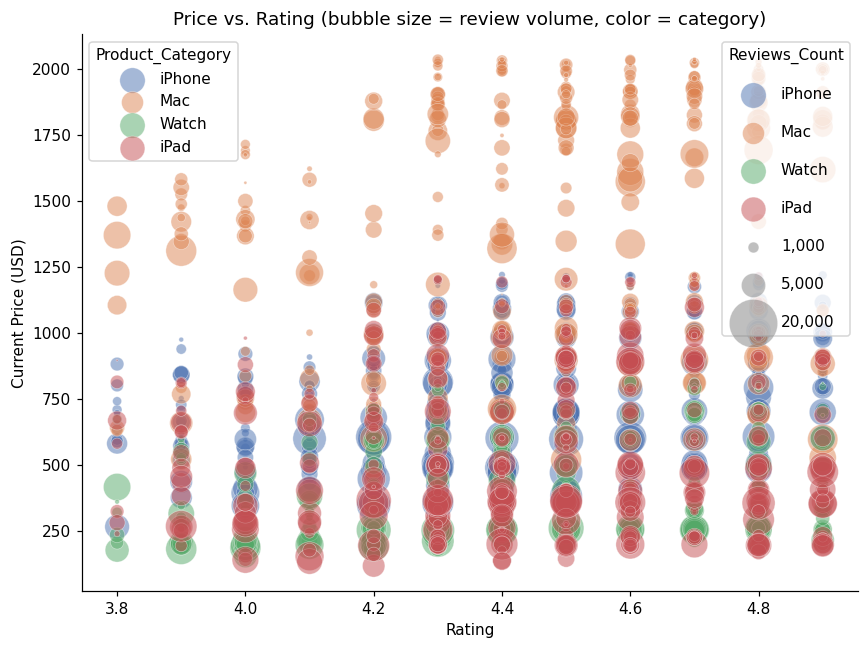

In [33]:
sample = df.sample(n=min(2000, len(df)), random_state=1)

cat_color = {"iPhone": "#4C72B0", "Mac": "#DD8452", "Watch": "#55A868", "iPad": "#C44E52"}

fig, ax = plt.subplots(figsize=(8, 6))
for cat, color in cat_color.items():
    d = sample[sample["Product_Category"] == cat]
    ax.scatter(
        d["Rating"],
        d["Current_Price_USD"],
        s=d["Reviews_Count"] / 20,
        color=color,
        alpha=0.5, edgecolor="white", linewidth=0.4, label=cat
    )

ax.set_xlabel("Rating")
ax.set_ylabel("Current Price (USD)")
ax.set_title("Price vs. Rating (bubble size = review volume, color = category)")

# Category legend
cat_legend = ax.legend(title="Product_Category", loc="upper left")
ax.add_artist(cat_legend)

# Size legend (reference bubbles for review count)
for reviews in [1000, 5000, 20000]:
    ax.scatter([], [], s=reviews / 20, color="gray", alpha=0.5,
               edgecolor="white", linewidth=0.4, label=f"{reviews:,}")
ax.legend(title="Reviews_Count", loc="upper right", labelspacing=1.5)

plt.tight_layout()
plt.show()

---
## Task 5 — The Submission Audit *(~2 min)*

The clock is almost out. Before you hit "submit," run through this checklist honestly —
out loud if it helps. Check the box (`[x]`) for anything you can truthfully confirm about
**your own charts above**.

- [ ] Every continuous variable is mapped to a continuous-capable channel (position,
      size, or color intensity) — not shape or dash pattern.
- [ ] Every bar chart's axis starts at zero.
- [ ] Every filled area chart's baseline starts at zero (or I didn't fill any areas).
- [ ] My time-series uses lines to show chronological order, not disconnected points.
- [ ] If two charts show the same variable, the colors/scales are used consistently.
- [ ] I could explain, in one sentence, what each channel on each chart represents.

Run the cell below to log your finish time.


In [34]:
elapsed_min = (time.time() - mission_start) / 60
print(f"🏁 SUBMITTED at {elapsed_min:0.1f} minutes into the mission.")
if elapsed_min <= 20:
    print("✅ On time. Priya nods and walks it into the stand-up.")
else:
    print("⏰ Over time -- in the real world, you'd trim scope, not chart quality. Note this for your reflection.")


🏁 SUBMITTED at 8.7 minutes into the mission.
✅ On time. Priya nods and walks it into the stand-up.


---
## 🪞 Reflection

Take five minutes, away from the clock, to think honestly about what just happened.
Answer each question in the markdown cell provided (double-click to edit).

**1. Time pressure and technique.** Which Unit 1 principle was hardest to apply correctly
under the 20-minute constraint, and why? Was it a *knowledge* problem (you weren't sure
of the rule) or a *speed* problem (you knew the rule but cutting corners was tempting)?

*Your answer:*


---

**2. Spot the near-miss.** Look back at your own charts. Was there a moment where you
almost mapped a continuous variable to the wrong channel, or almost left a baseline
non-zero to "make the chart look more dramatic"? What stopped you (or what didn't)?

*Your answer:*


---

**3. The cost of dishonest ink.** Recall the Principle of Proportional Ink. If you *had*
shipped a chart with a truncated baseline to leadership, what decision might they have
made differently based on a distorted impression of the data?

*Your answer:*


---

**4. Trade-offs under constraint.** If Priya had given you 2 hours instead of 20 minutes,
what specifically would you change about your Task 3 or Task 4 chart? (e.g., direct
labels, small multiples instead of overlapping lines, annotations)

*Your answer:*


---

**5. Beyond the classroom.** Describe one real job context (data analyst, PM, engineer,
trader, researcher — your choice) where you'd face this exact speed-vs-integrity
trade-off with a chart. What would *you* refuse to compromise on, even under a deadline?

1. Time pressure and technique.
The hardest principle to apply cleanly was the zero-baseline rule paired with axis orientation not because the rule itself was unclear, but because once the chart type flipped from vertical (ax.bar) to horizontal (ax.barh), the baseline needed to move from the y-axis to the x-axis too, and that step got skipped. That's more of a speed problem than a knowledge problem: I knew why zero-baselines matter, but under the clock I didn't re-check that a change in one line (bar → barh) had a downstream consequence for another line (set_ylim → set_xlim).

2. Spot the near-miss.
The near-miss was in the bubble chart (Task 3): the legend showed category via color but said nothing about what the bubble sizes meant, even though the title claimed size = review volume. It wasn't a "make it look dramatic" shortcut more a completeness gap. Nothing in the code would have thrown an error, so it's the kind of miss that ships silently unless you deliberately ask "can a reader decode every channel I used?"

3. The cost of dishonest ink.
If the truncated-baseline version had gone to leadership, a bar chart with a non-zero baseline can make a 5% difference between categories look like a 300% difference visually, since the bar heights are no longer proportional to the underlying values. Leadership could have over-invested in "underperforming" categories that were actually close in average price, or deprioritized a category that looked flat but wasn't a resourcing decision made on a distorted read of the gap, not the actual gap.

4. Trade-offs under constraint.
With 2 hours instead of 20 minutes I'd revisit the line chart (Task 2): direct end labels work fine for 2 lines, but I'd stress-test what happens with 4+ categories, since labels start colliding vertically at that point. I'd also add a size legend to the bubble chart from the start rather than as an afterthought, and check for NaNs in Reviews_Count and Rating before plotting instead of assuming the sample was clean.

5. Beyond the classroom.
As an ML/data analyst pushing a dashboard for a stakeholder review, this exact trade-off shows up constantly someone asks for "one more chart before the 3pm sync." What I wouldn't compromise on: the zero-baseline for bar charts and disclosing every visual channel in a legend. Those are the two failure modes that don't just look sloppy, they actively mislead someone who has less time than I do to scrutinize the chart and will just trust what they see.

